# Curvilinear Wave Equation

Check a readable spherical wave operator, then generate and run the default
`SinhCylindrical` stretched cylindrical wave project.

Navigation: [Index](../index.ipynb) |
Previous: [Basis Transforms](../4-curvilinear/basis_transforms.ipynb) |
Next: [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)

## Learning Goals

- Rewrite the wave operator for spherical coordinates as a readable warm-up.
- Connect symbolic curvilinear terms to a generated stretched cylindrical project.
- Generate, inspect, run, and validate the curvilinear project.

## Words for This Notebook

- **Curvilinear coordinates:** coordinates whose grid lines may curve, such as
  spherical coordinates.
- **Laplacian:** the space-derivative operator that appears in the wave equation.
- **Reference metric:** the metric for the chosen coordinates before adding physical fields.
- **Coordinate-specific file:** a generated file written for one coordinate system.
- **Residual:** zero means two formulas match after simplification.
- **Geometry term:** a derivative contribution caused by the coordinate system.
- **SinhCylindrical:** a cylindrical coordinate option with stretched radial and
  vertical coordinates.
- **BHaH:** the NRPy code-writing infrastructure used by this generator.
- **Method of Lines (MoL):** the time-stepping structure used by the generated code.

Use the code cells actively: first predict what should happen, then run the cell,
then explain the output in plain language.

## Table of Contents

- [Project Workflow Map](#project-workflow-map)
- [Challenges](#challenges)
- [Curvilinear Boundary Handling](#curvilinear-boundary-handling)
- [Spherical Symbolic Warm-Up](#spherical-symbolic-warm-up)
- [Default Project Bridge](#default-project-bridge)
- [Generated File Catalog](#generated-file-catalog)
- [Inspect Generated Project](#inspect-generated-project)
- [Validate Curvilinear Diagnostics](#validate-curvilinear-diagnostics)
- [Plot Curvilinear Diagnostics](#plot-curvilinear-diagnostics)

## Project Workflow Map

The notebook uses a simple symbolic check first, then follows the same idea into
a generated curvilinear project.

| Stage | Generated artifact | What it contributes |
| --- | --- | --- |
| Reference metric | symbolic RHS expressions | metric and geometry terms for the coordinates |
| Wave RHS | coordinate-specific `rhs_eval` source | updates `u` and `v` in that coordinate system |
| Boundary handling | `bcstruct_set_up.c`, `apply_bcs_*.c` | ghost-zone fills |
| Time stepping | `MoL/` sources | RK4 stages that call the RHS and boundary code |
| Diagnostics | `diagnostics/` and `out0d-*.txt` | sampled numerical-vs-exact errors |

## Challenges

- **Coordinate geometry:** spherical coordinates add radial and angular terms to
  the flat-space wave operator.
- **Coordinate singularities:** curvilinear ghost-zone points can map through
  coordinate singularities and need parity-aware boundary fills.
- **Generated variants:** the project writes coordinate-specific source files
  whose names must match the selected coordinate system.

| Challenge | Addressed By |
| --- | --- |
| Coordinate geometry | spherical symbolic residual and SinhCylindrical RHS check |
| Coordinate singularities | curvilinear boundary-handling section and generated BC files |
| Generated variants | generated file catalog and file checks |

## Curvilinear Boundary Handling

Curvilinear coordinates can have singular locations or symmetry axes. The
project does not ask the learner to implement those rules here, but it does show
where they enter the generated code:

- `bcstruct_set_up.c` classifies ghost-zone points and stores source points and
  parity signs for inner-boundary fills.
- `apply_bcs_inner_only.c` copies mapped source values into inner-boundary ghost
  zones with the stored parity.
- `apply_bcs_outerradiation_and_inner.c` applies outgoing radiation behavior at
  pure outer boundaries and then fills inner-boundary points.

The later file checks confirm that these pieces were generated before the run.

## Spherical Symbolic Warm-Up
For spherical coordinates, the scalar Laplacian contains radial, angular, and
geometry terms:

$$
\nabla^2 u =
\partial_r^2 u + \frac{1}{r^2}\partial_\theta^2 u
+ \frac{1}{r^2\sin^2\theta}\partial_\phi^2 u
+ \frac{2}{r}\partial_r u
+ \frac{\cos\theta}{r^2\sin\theta}\partial_\theta u.
$$

The residual verifies that NRPy's expression contains these terms.

| Math Symbol | NRPy Symbol | Meaning |
| --- | --- | --- |
| `r` | `xx0` | radial coordinate |
| `theta` | `xx1` | polar angle |
| `phi` | `xx2` | azimuthal angle |
| `partial_r u` | `uu_dD0` | first radial derivative |
| `partial_r^2 u` | `uu_dDD00` | second radial derivative |

## Import SymPy for Curvilinear Checks

These imports expose the NRPy and Python tools used in the next steps.

In [1]:
import sympy as sp

## Import Curvilinear Wave Tools

These imports expose the NRPy modules used below.

In [2]:
import nrpy.grid as grid
import nrpy.params as par
from nrpy.equations.wave_equation.WaveEquation_RHSs import WaveEquation_RHSs
from nrpy.equations.wave_equation.WaveEquationCurvilinear_RHSs import (
    WaveEquationCurvilinear_RHSs,
)

## Step 1: Construct the Spherical Wave Right-Hand Side

Construct the spherical wave-equation right-hand side.

In [3]:
for name in ["uu", "vv", "uu_rhs", "vv_rhs"]:
    grid.glb_gridfcs_dict.pop(name, None)
spherical_rhs = WaveEquationCurvilinear_RHSs(
    CoordSystem="Spherical", enable_rfm_precompute=False
)
print("uu_rhs =", spherical_rhs.uu_rhs)
print("vv_rhs =", spherical_rhs.vv_rhs)

Setting up reference_metric[Spherical]...


uu_rhs = vv
vv_rhs = wavespeed**2*(2*uu_dD0/xx0 + uu_dD1*cos(xx1)/(xx0**2*sin(xx1)) + uu_dDD00 + uu_dDD11/xx0**2 + uu_dDD22/(xx0**2*sin(xx1)**2))


## Step 2: Build the Expected Spherical Laplacian Terms

Build the expected spherical Laplacian terms from the formula above.

In [4]:
symbols = {symbol.name: symbol for symbol in spherical_rhs.vv_rhs.free_symbols}
wavespeed = symbols["wavespeed"]
xx0, xx1 = symbols["xx0"], symbols["xx1"]
uu_dD0, uu_dD1 = symbols["uu_dD0"], symbols["uu_dD1"]
uu_dDD00 = symbols["uu_dDD00"]
uu_dDD11 = symbols["uu_dDD11"]
uu_dDD22 = symbols["uu_dDD22"]
expected = wavespeed**2 * (
    uu_dDD00
    + uu_dDD11 / xx0**2
    + uu_dDD22 / (xx0**2 * sp.sin(xx1) ** 2)
    + 2 * uu_dD0 / xx0
    + uu_dD1 * sp.cos(xx1) / (xx0**2 * sp.sin(xx1))
)
print("expected spherical right-hand side constructed")

expected spherical right-hand side constructed


## Validation Check: Compare Against the Spherical Formula

Compare the generated expression against the expected formula.

In [5]:
residual = sp.trigsimp(sp.simplify(spherical_rhs.vv_rhs - expected))
print("Spherical right-hand-side residual:", residual)
if residual != 0:
    raise RuntimeError("Expected the residual to vanish.")

Spherical right-hand-side residual: 0


## Validation Check: Compare Against Cartesian Coordinates

When the curvilinear RHS builder is asked for Cartesian coordinates, it should
reduce to the Cartesian RHS. This isolates the reference-metric machinery from
the wave equation itself.

In [6]:
for name in ["uu", "vv", "uu_rhs", "vv_rhs"]:
    grid.glb_gridfcs_dict.pop(name, None)
cartesian_rhs = WaveEquation_RHSs()
for name in ["uu", "vv", "uu_rhs", "vv_rhs"]:
    grid.glb_gridfcs_dict.pop(name, None)
curvilinear_cartesian_rhs = WaveEquationCurvilinear_RHSs(
    CoordSystem="Cartesian", enable_rfm_precompute=False
)
cartesian_residual = sp.simplify(
    curvilinear_cartesian_rhs.vv_rhs - cartesian_rhs.vv_rhs
)
print(
    "Cartesian vv_rhs residual:",
    cartesian_residual,
)
if cartesian_residual != 0:
    raise RuntimeError("Expected the Cartesian residual to vanish.")

Setting up reference_metric[Cartesian]...
Cartesian vv_rhs residual: 0


## Default Project Bridge

The installed project generator used below writes a default `SinhCylindrical`
project. The spherical calculation above remains useful because it exposes the
same reference-metric pattern in a compact formula: metric-inverse terms multiply
second derivatives, and contracted-Christoffel terms multiply first derivatives.

| Check | Coordinate System | Evidence |
| --- | --- | --- |
| Symbolic warm-up | `Spherical` | hand-readable residual is zero |
| Generated project | `SinhCylindrical` | generated RHS, boundary files, and diagnostics |

## Validation Check: Build the SinhCylindrical RHS

This cell asks NRPy for the same coordinate option used by the project
generator. The output is long, so inspect it only for the stretched-coordinate
parameters; the full generated source is inspected later.

In [7]:
for name in ["uu", "vv", "uu_rhs", "vv_rhs"]:
    grid.glb_gridfcs_dict.pop(name, None)
sinh_cylindrical_rhs = WaveEquationCurvilinear_RHSs(
    CoordSystem="SinhCylindrical", enable_rfm_precompute=False
)
required_parameters = {"AMPLRHO", "SINHWRHO", "AMPLZ", "SINHWZ"}
rhs_symbols = {symbol.name for symbol in sinh_cylindrical_rhs.vv_rhs.free_symbols}
missing_parameters = required_parameters.difference(rhs_symbols)
print("SinhCylindrical parameters:", sorted(required_parameters))
print("SinhCylindrical vv_rhs =", sinh_cylindrical_rhs.vv_rhs)
if missing_parameters:
    raise RuntimeError(
        "Missing SinhCylindrical parameters: "
        f"{sorted(missing_parameters)}"
    )

Setting up reference_metric[SinhCylindrical]...


SinhCylindrical parameters: ['AMPLRHO', 'AMPLZ', 'SINHWRHO', 'SINHWZ']
SinhCylindrical vv_rhs = wavespeed**2*(-uu_dD0*((2*exp(xx0/SINHWRHO)/SINHWRHO**2 - 2*exp(-xx0/SINHWRHO)/SINHWRHO**2)*(exp(1/SINHWRHO) - exp(-1/SINHWRHO))**2/(2*AMPLRHO**2*(exp(xx0/SINHWRHO)/SINHWRHO + exp(-xx0/SINHWRHO)/SINHWRHO)**3) - (2*exp(xx0/SINHWRHO)/SINHWRHO + 2*exp(-xx0/SINHWRHO)/SINHWRHO)*(exp(1/SINHWRHO) - exp(-1/SINHWRHO))**2/(2*AMPLRHO**2*(exp(xx0/SINHWRHO)/SINHWRHO + exp(-xx0/SINHWRHO)/SINHWRHO)**2*(exp(xx0/SINHWRHO) - exp(-xx0/SINHWRHO)))) - uu_dD2*(2*exp(xx2/SINHWZ)/SINHWZ**2 - 2*exp(-xx2/SINHWZ)/SINHWZ**2)*(exp(1/SINHWZ) - exp(-1/SINHWZ))**2/(2*AMPLZ**2*(exp(xx2/SINHWZ)/SINHWZ + exp(-xx2/SINHWZ)/SINHWZ)**3) + uu_dDD22*(exp(1/SINHWZ) - exp(-1/SINHWZ))**2/(AMPLZ**2*(exp(xx2/SINHWZ)/SINHWZ + exp(-xx2/SINHWZ)/SINHWZ)**2) + uu_dDD00*(exp(1/SINHWRHO) - exp(-1/SINHWRHO))**2/(AMPLRHO**2*(exp(xx0/SINHWRHO)/SINHWRHO + exp(-xx0/SINHWRHO)/SINHWRHO)**2) + uu_dDD11*(exp(1/SINHWRHO) - exp(-1/SINHWRHO))**2/(AMPLRHO*

## Generate, Build, and Run the Curvilinear Project
The real generator writes coordinate-specific C update routines and diagnostics.
The parameter file is shortened only after generation so notebook execution
remains quick.

## Generated File Catalog

| Name | Purpose | What to Inspect |
| --- | --- | --- |
| `wave_equation_curvilinear.par` | runtime settings | coordinates, wave speed, output cadence |
| `SinhCylindrical/rhs_eval__rfm__SinhCylindrical.c` | coordinate RHS | geometry terms |
| `bcstruct_set_up.c` | boundary metadata | source points and parity setup |
| `apply_bcs_inner_only.c` | inner-boundary fill | parity-aware ghost-zone copies |
| `apply_bcs_outerradiation_and_inner.c` | outer and inner BCs | radiation and parity fill |
| `diagnostics/diagnostics.c` | diagnostic writer | output file names |
| `BHaH_function_prototypes.h` | function declarations | callable generated functions |
| `out0d-grid*.txt` | diagnostics | relative errors and sampled `u` values |

## Import Curvilinear Project Execution Helpers

These standard-library tools run commands, manage temporary project directories,
and clean command output.

If you are new to Python, skim this helper cell on a first pass. Its job is to
run terminal commands, shorten long command output, and stop clearly if a
required tool is missing.

In [8]:
from pathlib import Path
import math
import re
import shutil
import subprocess
import sys
import tempfile


def clean_command_output(text):
    cleaned = re.sub(r"\x1b\[[0-?]*[ -/]*[@-~]", "", text or "")
    return cleaned.replace(str(WORKSPACE), "<workspace>")


def run_command(args, cwd, timeout):
    try:
        result = subprocess.run(
            args,
            cwd=cwd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=True,
            timeout=timeout,
        )
    except FileNotFoundError as exc:
        raise RuntimeError(f"Required command is missing: {args[0]}") from exc
    except subprocess.CalledProcessError as exc:
        print(clean_command_output(exc.stdout))
        raise RuntimeError(f"Command failed: {' '.join(map(str, args))}") from exc
    return clean_command_output(result.stdout)


def require_toolchain():
    if shutil.which("make") is None:
        raise RuntimeError(
            "This notebook requires make to build the generated project."
        )
    if not any(shutil.which(name) for name in ["cc", "gcc", "clang"]):
        raise RuntimeError(
            "This notebook requires a C compiler such as cc, gcc, or clang."
        )


def replace_once(text, old, new, label):
    count = text.count(old)
    if count != 1:
        raise RuntimeError(
            f"Expected exactly one {label} setting to replace; found {count}."
        )
    print("updated runtime setting:", label)
    return text.replace(old, new, 1)

## Step 3: Create a Curvilinear Project Workspace

The workspace keeps generated files separate from the tutorial source tree.

In [9]:
PROJECT_NAME = "wave_equation_curvilinear"
workspace_manager = tempfile.TemporaryDirectory(
    prefix="nrpy_tutorial_curvi_", dir=Path.cwd()
)
WORKSPACE = Path(workspace_manager.name)
PROJECT_DIR = WORKSPACE / "project" / PROJECT_NAME
print("workspace:", WORKSPACE)
print("project path:", PROJECT_DIR)

workspace: /work/3-wave_equation/nrpy_tutorial_curvi_4b_z4pe5
project path: /work/3-wave_equation/nrpy_tutorial_curvi_4b_z4pe5/project/wave_equation_curvilinear


## Step 4: Generate the Default SinhCylindrical Project

This command invokes the same module a learner can run from a terminal and then
verifies that the project directory exists.

In [10]:
command = [sys.executable, "-m", "nrpy.examples.wave_equation_curvilinear"]
print("generator command: python -m nrpy.examples.wave_equation_curvilinear")
output = run_command(command, WORKSPACE, timeout=300)
for line in output.splitlines():
    if line.strip():
        print(line.rstrip())
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(PROJECT_DIR)
print("generated project:", PROJECT_DIR.relative_to(WORKSPACE))

generator command: python -m nrpy.examples.wave_equation_curvilinear


Setting up reference_metric[SinhCylindrical]...
In 0.004s, worker completed task 'register_CFunction_initial_data'
In 0.003s, worker completed task '_register_CFunction_diagnostics'
In 0.003s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.003s, worker completed task 'register_CFunction_diagnostics_nearest_2d_xy_and_yz_planes'
In 0.004s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_and_z_axes'
In 0.003s, worker completed task 'register_CFunction_diagnostics_volume_integration'
In 0.003s, worker completed task 'register_CFunction_diagnostics_nearest'
In 0.011s, worker completed task 'register_CFunction__Cart_to_xx_and_nearest_i0i1i2'
In 0.029s, worker completed task 'register_CFunction_xx_to_Cart'
In 0.045s, worker completed task 'register_CFunctions'
In 0.049s, worker completed task 'register_CFunction_rhs_eval'
In 0.061s, worker completed task 'register_CFunction_initial_data_exact'
In 0.063s, worker completed task 'register_CFunc

## Step 5: Shorten Runtime Parameters

Only runtime values are changed so the notebook run finishes quickly. After the
edit, inspect `wavespeed`, `sigma`, `outer_bc_type`, `t_final`,
`diagnostics_output_every`, and `convergence_factor`.

In [11]:
parfile = PROJECT_DIR / "wave_equation_curvilinear.par"
par_text = parfile.read_text(encoding="utf-8")
par_text = replace_once(par_text, "t_final = 8.0", "t_final = 0.2", "final time")
par_text = replace_once(
    par_text,
    "diagnostics_output_every = 0.5",
    "diagnostics_output_every = 0.1",
    "diagnostic output interval",
)
par_text = replace_once(
    par_text,
    "output_progress_every = 1",
    "output_progress_every = 1000000",
    "progress output interval",
)
parfile.write_text(par_text, encoding="utf-8")
print(f"--- runtime {parfile.name} ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))

updated runtime setting: final time
updated runtime setting: diagnostic output interval
updated runtime setting: progress output interval
--- runtime wave_equation_curvilinear.par ---
#### wave_equation_curvilinear BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.CurviBoundaryConditions.register_all
outer_bc_type = "radiation"     # (char[50])
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.2                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.checkpointing
checkpoi

## Inspect Generated Project

The next cells verify the generated files, inspect the SinhCylindrical RHS and
boundary-code artifacts, build the executable, and run diagnostics.

## Step 6: Check Coordinate-Specific and Boundary Files

The file check confirms that the generated project wrote the selected coordinate
RHS and the boundary-condition files needed by curvilinear coordinates.

In [12]:
required = [
    "Makefile",
    "BHaH_function_prototypes.h",
    "SinhCylindrical/rhs_eval__rfm__SinhCylindrical.c",
    "bcstruct_set_up.c",
    "apply_bcs_inner_only.c",
    "apply_bcs_outerradiation_and_inner.c",
    "diagnostics/diagnostics.c",
    "wave_equation_curvilinear.par",
]
for relative_path in required:
    path = PROJECT_DIR / relative_path
    if not path.exists():
        raise FileNotFoundError(path)
print("checked coordinate-specific and boundary generated files")

checked coordinate-specific and boundary generated files


## Step 7: Inspect the Generated Inventory

The inventory identifies the generated files relevant to this lesson.

In [13]:
print("selected coordinate files:")
for relative_path in required:
    print(relative_path)
for directory in sorted(
    path.name
    for path in PROJECT_DIR.iterdir()
    if path.is_dir() and path.name not in {"MoL", "diagnostics", "intrinsics"}
):
    print(directory + "/")

selected coordinate files:
Makefile
BHaH_function_prototypes.h
SinhCylindrical/rhs_eval__rfm__SinhCylindrical.c
bcstruct_set_up.c
apply_bcs_inner_only.c
apply_bcs_outerradiation_and_inner.c
diagnostics/diagnostics.c
wave_equation_curvilinear.par
SinhCylindrical/


## Step 8: Read the SinhCylindrical RHS Source

The full generated source file below is the compiled version of the
SinhCylindrical right-hand side. On a first pass, look for:

- the function name that contains `SinhCylindrical`;
- the grid loop over interior points;
- references to coordinate data or stretch parameters;
- assignments to right-hand-side fields.

In [14]:
sinh_rhs_source = PROJECT_DIR / "SinhCylindrical" / "rhs_eval__rfm__SinhCylindrical.c"
print(sinh_rhs_source.read_text(encoding="utf-8", errors="replace"))

#include "BHaH_defines.h"
#include "intrinsics/simd_intrinsics.h"

/**
 * Kernel: rhs_eval_host.
 * Set RHSs for wave equation.
 */
static void rhs_eval_host(const params_struct *restrict params, const rfm_struct *restrict rfmstruct, const REAL *restrict auxevol_gfs,
                          const REAL *restrict in_gfs, REAL *restrict rhs_gfs, const REAL NOSIMDwavespeed) {
  MAYBE_UNUSED const int Nxx_plus_2NGHOSTS0 = params->Nxx_plus_2NGHOSTS0;
  MAYBE_UNUSED const int Nxx_plus_2NGHOSTS1 = params->Nxx_plus_2NGHOSTS1;
  MAYBE_UNUSED const int Nxx_plus_2NGHOSTS2 = params->Nxx_plus_2NGHOSTS2;

  const REAL NOSIMDinvdxx0 = params->invdxx0;
  MAYBE_UNUSED const REAL_SIMD_ARRAY invdxx0 = ConstSIMD(NOSIMDinvdxx0);
  const REAL NOSIMDinvdxx1 = params->invdxx1;
  MAYBE_UNUSED const REAL_SIMD_ARRAY invdxx1 = ConstSIMD(NOSIMDinvdxx1);
  const REAL NOSIMDinvdxx2 = params->invdxx2;
  MAYBE_UNUSED const REAL_SIMD_ARRAY invdxx2 = ConstSIMD(NOSIMDinvdxx2);

  MAYBE_UNUSED const REAL_SIMD_ARRAY waves

## Step 9: Build the Executable

The build step compiles generated C after checking that external build tools are
available. The first compile lines should include boundary-condition files,
coordinate RHS files, diagnostics, and time stepping.

In [15]:
require_toolchain()
build_output = run_command(["make", "-j2"], PROJECT_DIR, timeout=300)
executable = PROJECT_DIR / PROJECT_NAME
if not executable.is_file():
    raise FileNotFoundError(executable)
build_lines = [line for line in build_output.splitlines() if line.strip()]
print("build completed")
print("executable:", executable.relative_to(PROJECT_DIR))
print("compiler output line count:", len(build_lines))
for line in build_lines[:5]:
    print(line)

build completed
executable: wave_equation_curvilinear
compiler output line count: 51
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c apply_bcs_inner_only.c -o apply_bcs_inner_only.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c apply_bcs_inner_only_specific_gfs.c -o apply_bcs_inner_only_specific_gfs.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c apply_bcs_outerextrap_and_inner.c -o apply_bcs_outerextrap_and_inner.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c apply_bcs_outerradiation_and_inner.c -o apply_bcs_outerradiation_and_inner.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c bcstruct_set_up.c -o bcstruct_set_up.o


## Step 10: Run the Executable

The run produces diagnostic files that are inspected in the following cells.

In [16]:
run_output = run_command([f"./{PROJECT_NAME}", "2.0"], PROJECT_DIR, timeout=120)
print("run output:")
for line in run_output.splitlines()[:12]:
    if line.strip():
        print(line.rstrip())

run output:
It: 0 t=0.000 / 0.2 = 0.00% dt=1/379.8 | t/h=0.00 ETA 0h00m00s
WRITING CHECKPOINT: cd struct size = 168 time=0.000000e+00
FINISHED WRITING CHECKPOINT


## Validate Curvilinear Diagnostics

Each diagnostic row stores time, relative `u` error, relative `v` error,
numerical `u`, and exact `u` at a coordinate-appropriate sampled point. The
exact solution is the trusted reference; the tolerances catch broken runs
without requiring roundoff-level agreement.

In [17]:
EXPECTED_DIAGNOSTIC_COLUMNS = 5
MAX_ABS_UU_RELERROR = 1.0e-5
MAX_ABS_VV_RELERROR = 1.0e-3
print("maximum allowed absolute relative u error:", MAX_ABS_UU_RELERROR)
print("maximum allowed absolute relative v error:", MAX_ABS_VV_RELERROR)
diagnostics = sorted(PROJECT_DIR.glob("out0d-grid*.txt"))
if not diagnostics:
    raise FileNotFoundError("No diagnostic files were produced.")
diagnostic_rows = {}
for diagnostic in diagnostics:
    rows = [
        [float(value) for value in line.split()]
        for line in diagnostic.read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip() and not line.lstrip().startswith("#")
    ]
    if len(rows) < 2:
        raise RuntimeError(f"Expected at least two rows in {diagnostic.name}.")
    for row in rows:
        if len(row) != EXPECTED_DIAGNOSTIC_COLUMNS:
            raise RuntimeError(
                f"Expected {EXPECTED_DIAGNOSTIC_COLUMNS} columns in {diagnostic.name}."
            )
    final_row = rows[-1]
    final_abs_uu_relerror = abs(final_row[1])
    final_abs_vv_relerror = abs(final_row[2])
    if not math.isfinite(final_abs_uu_relerror):
        raise RuntimeError(f"Expected a finite u error in {diagnostic.name}.")
    if not math.isfinite(final_abs_vv_relerror):
        raise RuntimeError(f"Expected a finite v error in {diagnostic.name}.")
    if final_abs_uu_relerror > MAX_ABS_UU_RELERROR:
        raise RuntimeError(
            "Expected absolute u error below "
            f"{MAX_ABS_UU_RELERROR} in {diagnostic.name}."
        )
    if final_abs_vv_relerror > MAX_ABS_VV_RELERROR:
        raise RuntimeError(
            "Expected absolute v error below "
            f"{MAX_ABS_VV_RELERROR} in {diagnostic.name}."
        )
    diagnostic_rows[diagnostic] = rows
    print(diagnostic.name, "rows:", len(rows), "last row:", final_row)

maximum allowed absolute relative u error: 1e-05
maximum allowed absolute relative v error: 0.001
out0d-grid00-SinhCylindrical-conv_factor-2.00.txt rows: 2 last row: [0.1000400197985105, 1.963821815503563e-09, -2.033720488457365e-06, 3.996661711363614, 3.996661703514882]


## Plot Curvilinear Diagnostics

The files now represent different coordinate choices. Plotting sampled absolute
relative errors makes the comparison about numerical behavior, not just file
names.

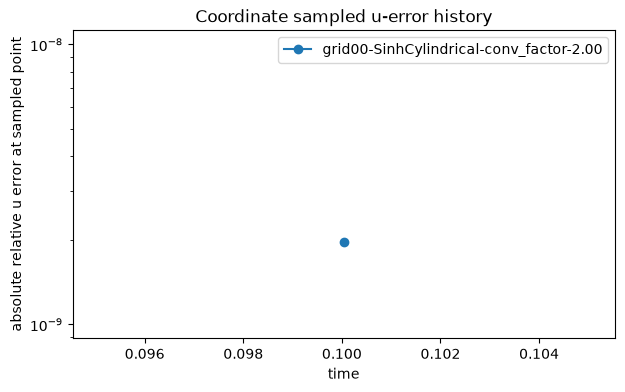

In [18]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 4))
for diagnostic, rows in diagnostic_rows.items():
    positive_rows = [row for row in rows if abs(row[1]) > 0.0]
    times = [row[0] for row in positive_rows]
    errors = [abs(row[1]) for row in positive_rows]
    label = diagnostic.stem.replace("out0d-", "")
    plt.plot(times, errors, marker="o", label=label)
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("absolute relative u error at sampled point")
plt.title("Coordinate sampled u-error history")
plt.legend()
plt.show()

The spherical residual gives a hand-readable symbolic check. The generated
project output then shows the default SinhCylindrical operator, boundary
metadata, and diagnostics inside a compiled multi-file code. The runtime
parameter file is the one used for the displayed diagnostics.

## Learning Check

After the spherical residual, identify which terms come from radial
derivatives and which come from angular geometry. Then explain why the
residual is zero.

## Continue to Boundary Conditions
- [Reference-Metric Applications](../4-curvilinear/reference_metric_applications.ipynb)
- [Basis Transforms](../4-curvilinear/basis_transforms.ipynb)
- [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)
- [GeneralRFM and Fisheye Coordinates](../4-curvilinear/generalrfm_and_fisheye.ipynb)